# 05 EDA - Multivariate

## Correlation Heatmap (Numerical Variables)

This heatmap shows pairwise correlations among all numerical variables, including `Sales`.
Correlation values are displayed inside each cell for readability.


In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white')


In [3]:
clean_path = Path('../data/processed/ElectraHub_Data_cleaned.csv')
raw_path = Path('../data/raw/ElectraHub_Data.csv')

data_path = clean_path if clean_path.exists() else raw_path
df = pd.read_csv(data_path)

print(f'Loaded: {data_path.name}')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: ElectraHub_Data_cleaned.csv
Shape: 3,000 rows x 16 columns


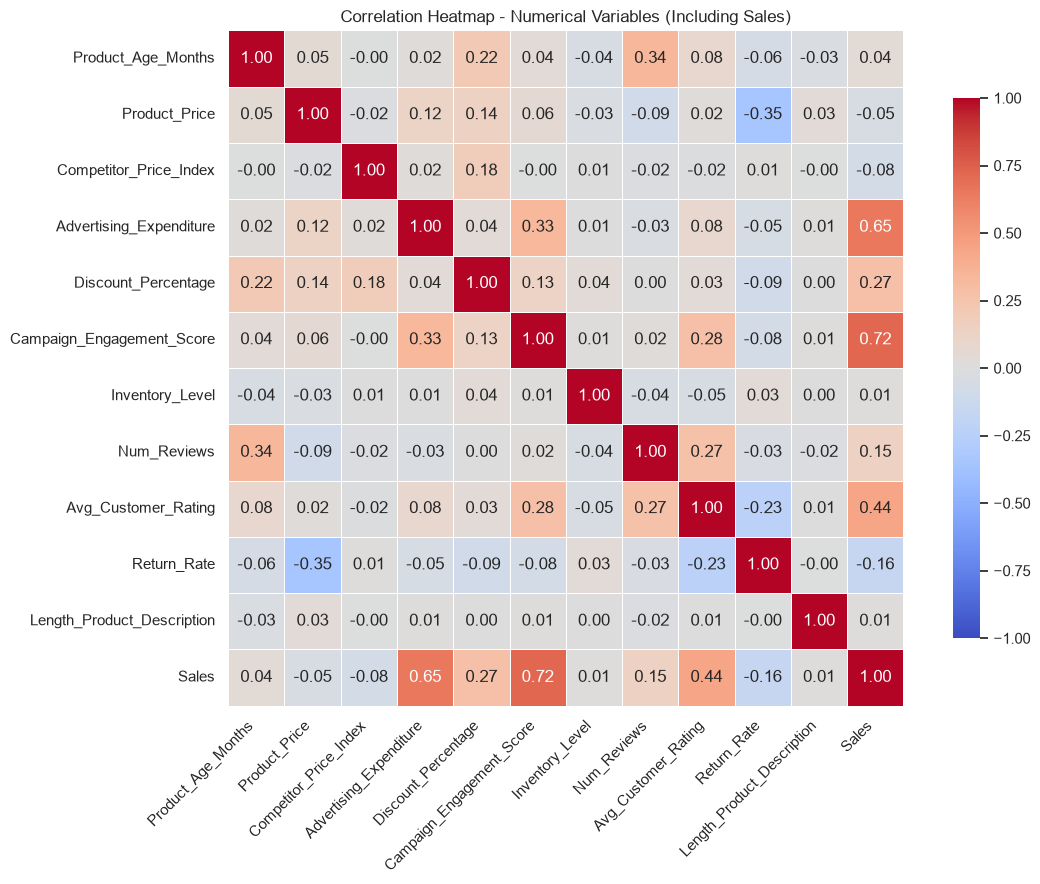

In [4]:
num_df = df.select_dtypes(include=['number'])

corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap - Numerical Variables (Including Sales)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature Ranking by Correlation with Sales

Horizontal bar chart of numerical features ranked by correlation with `Sales`
from strongest positive to strongest negative.


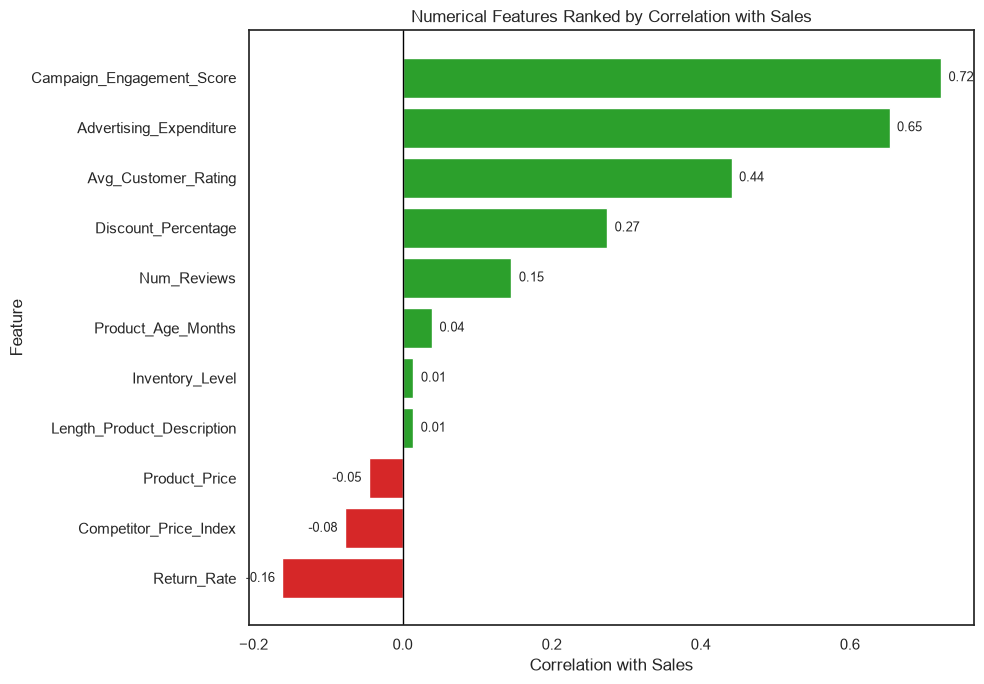

Ranked correlations with Sales (positive to negative):
Campaign_Engagement_Score     0.722338
Advertising_Expenditure       0.653183
Avg_Customer_Rating           0.441408
Discount_Percentage           0.274456
Num_Reviews                   0.146024
Product_Age_Months            0.039468
Inventory_Level               0.014628
Length_Product_Description    0.014302
Product_Price                -0.045422
Competitor_Price_Index       -0.077452
Return_Rate                  -0.161307


In [5]:
# Correlation of each numerical feature with Sales
sales_corr = (
    num_df.corr(numeric_only=True)['Sales']
    .drop('Sales')
    .sort_values(ascending=False)
)

plot_df = sales_corr.reset_index()
plot_df.columns = ['feature', 'correlation_with_sales']

plt.figure(figsize=(10, 7))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in plot_df['correlation_with_sales']]

plt.barh(plot_df['feature'], plot_df['correlation_with_sales'], color=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Numerical Features Ranked by Correlation with Sales')
plt.xlabel('Correlation with Sales')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # strongest positive at top

for i, v in enumerate(plot_df['correlation_with_sales']):
    x_pos = v + (0.01 if v >= 0 else -0.01)
    ha = 'left' if v >= 0 else 'right'
    plt.text(x_pos, i, f'{v:.2f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

print('Ranked correlations with Sales (positive to negative):')
print(sales_corr.to_string())

## Pairplot for Key Modeling Variables

Pairplot for the following variables to visually scan pairwise relationships and univariate distributions:
- `Campaign_Engagement_Score`
- `Advertising_Expenditure`
- `Avg_Customer_Rating`
- `Discount_Percentage`
- `Sales`


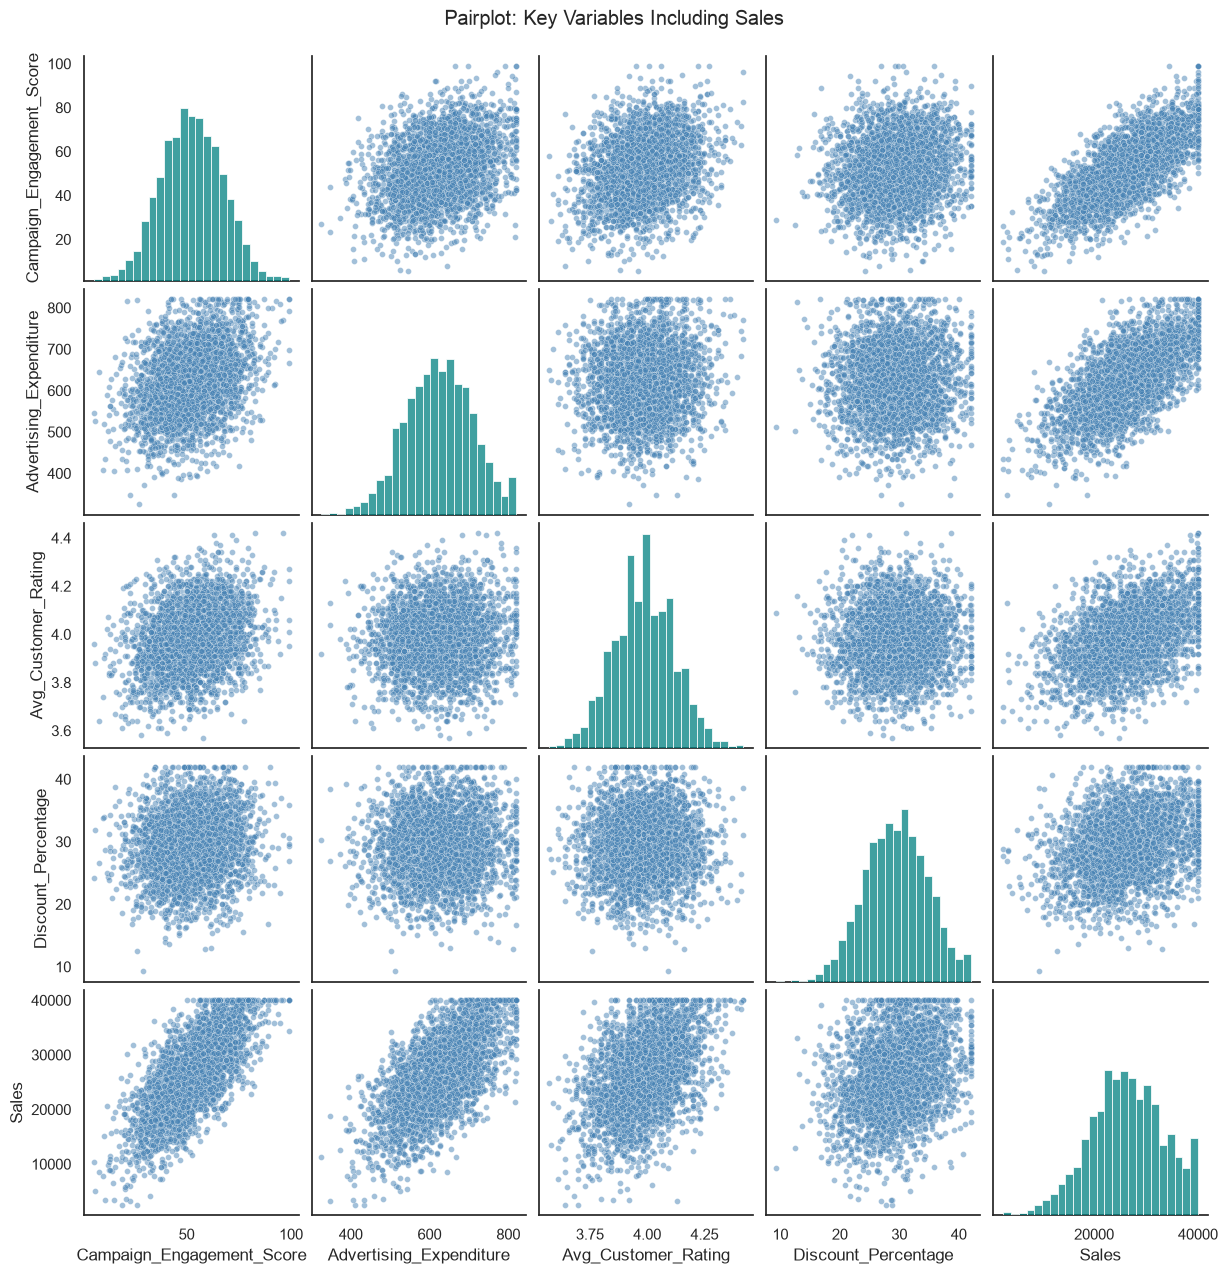

In [6]:
pairplot_cols = [
    'Campaign_Engagement_Score',
    'Advertising_Expenditure',
    'Avg_Customer_Rating',
    'Discount_Percentage',
    'Sales'
]

pair_df = df[pairplot_cols].dropna().copy()

g = sns.pairplot(
    pair_df,
    vars=pairplot_cols,
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 18, 'color': 'steelblue'},
    diag_kws={'bins': 25, 'color': 'teal', 'alpha': 0.75}
)
g.fig.suptitle('Pairplot: Key Variables Including Sales', y=1.02)
plt.show()

## Average Sales by Campaign Type and Region

Grouped bar chart of mean `Sales` by `Campaign_Type`, with bars grouped by `Region`,
so region-campaign combinations can be compared directly.


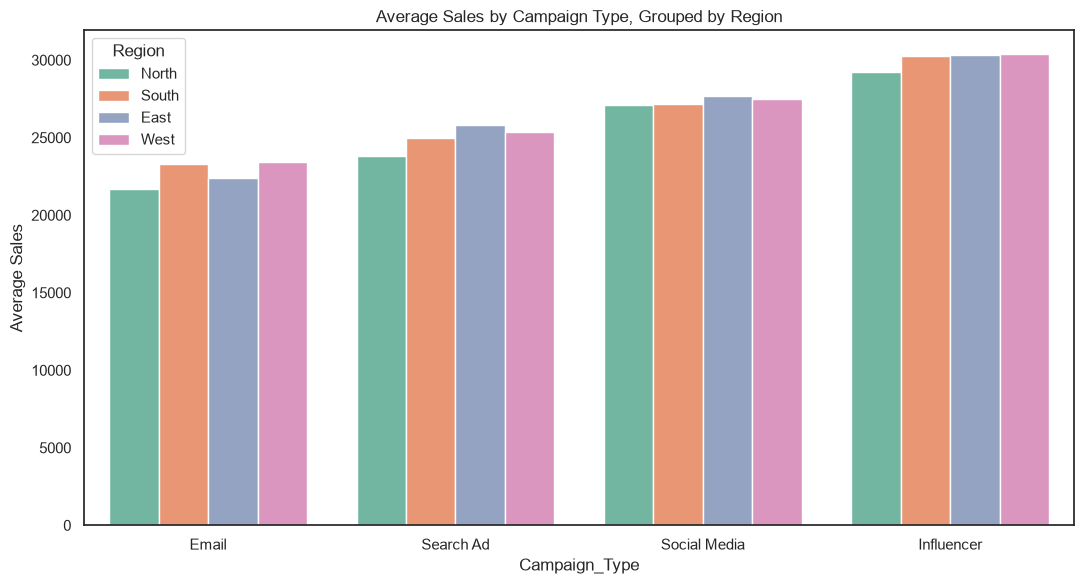

Average Sales table (Campaign_Type x Region):
Region            North     South      East      West
Campaign_Type                                        
Email          21665.09  23312.52  22411.99  23395.73
Search Ad      23792.02  24999.32  25802.42  25365.27
Social Media   27127.11  27137.70  27657.69  27493.62
Influencer     29241.28  30266.39  30317.88  30391.18


In [7]:
campaign_order = ['Email', 'Search Ad', 'Social Media', 'Influencer']
region_order = ['North', 'South', 'East', 'West']

plot_df = df.copy()
plot_df['Campaign_Type'] = plot_df['Campaign_Type'].astype(str).str.strip()
plot_df['Region'] = plot_df['Region'].astype(str).str.strip()

# Keep only categories that exist in data while preserving preferred order
campaign_in_data = [c for c in campaign_order if c in set(plot_df['Campaign_Type'])]
region_in_data = [r for r in region_order if r in set(plot_df['Region'])]

agg = (
    plot_df.groupby(['Campaign_Type', 'Region'], as_index=False)['Sales']
    .mean()
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=agg,
    x='Campaign_Type',
    y='Sales',
    hue='Region',
    order=campaign_in_data,
    hue_order=region_in_data,
    palette='Set2'
)

plt.title('Average Sales by Campaign Type, Grouped by Region')
plt.xlabel('Campaign_Type')
plt.ylabel('Average Sales')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

pivot_view = agg.pivot(index='Campaign_Type', columns='Region', values='Sales').reindex(index=campaign_in_data, columns=region_in_data)
print('Average Sales table (Campaign_Type x Region):')
print(pivot_view.round(2).to_string())

## Sales by Popularity and Product Category (Grouped Box Plot)

Grouped box plot of `Sales` across `Popularity` levels, split by `Product_Category`
(`Mobile` and `Tablet`) to compare whether the popularity pattern is consistent.


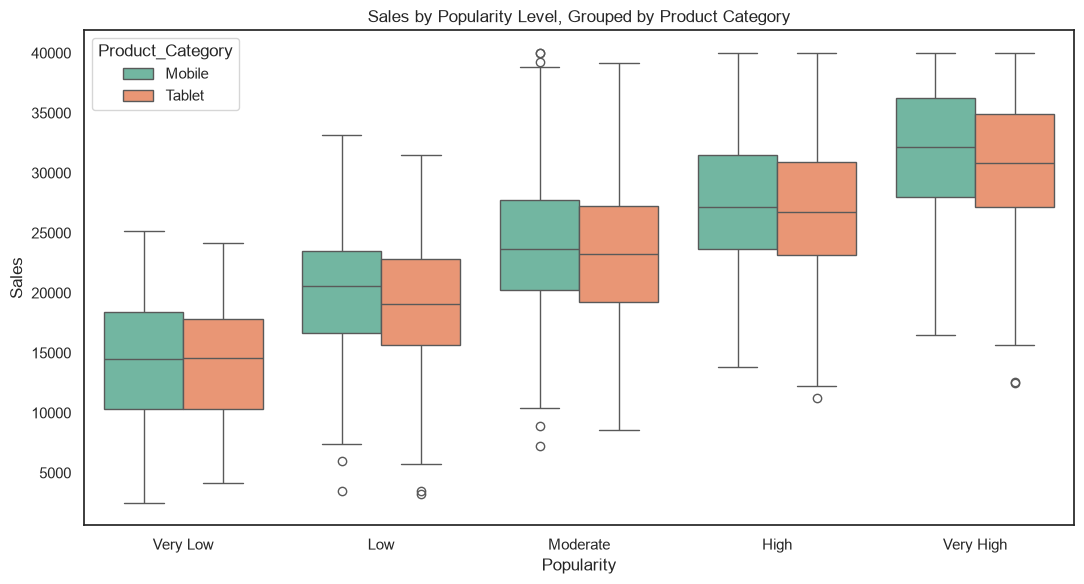

In [8]:
popularity_order = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
category_order = ['Mobile', 'Tablet']

plot_df = df.copy()
plot_df['Popularity'] = plot_df['Popularity'].astype(str).str.strip()
plot_df['Product_Category'] = plot_df['Product_Category'].astype(str).str.strip()

# Keep only known categories in preferred order if they exist in data
pop_in_data = [p for p in popularity_order if p in set(plot_df['Popularity'])]
cat_in_data = [c for c in category_order if c in set(plot_df['Product_Category'])]

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=plot_df,
    x='Popularity',
    y='Sales',
    hue='Product_Category',
    order=pop_in_data,
    hue_order=cat_in_data,
    palette='Set2'
)
plt.title('Sales by Popularity Level, Grouped by Product Category')
plt.xlabel('Popularity')
plt.ylabel('Sales')
plt.legend(title='Product_Category')
plt.tight_layout()
plt.show()